In [4]:
# Set up for plotting
# Params for clean and minimalistic plots

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    #'figure.figsize': (6*2, 2*4.5),
    'font.size': 16.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

from pathlib import Path

PLOT_ROOT = Path.cwd() / "Plots"

In [5]:
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm

sys.path.insert(0, str(Path.cwd()))
from helpers import (
    load_tt_matrix,
    load_blocks_with_bezirk,
    load_commuting_data,
    normalize_commuting_columns,
    build_block_bezirk_map,
    aggregate_tt_to_bezirke,
    build_gravity_df,
    run_ols_gravity,
    run_poisson_gravity,
    run_gamma_gravity,
    partial_out_fe,
    format_gravity_latex_table,
)

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().parent                    # QSE-Tutorial/
DATA_ROOT  = REPO_ROOT / "Data"
#ARSW_DIR   = REPO_ROOT / "arsw_teaching" / "data"

TTM_PATH  = Path.cwd() / "TTM" / "sample_travel_time_matrix.parquet"
#BLOCKS_SHP = DATA_ROOT / "Shapefiles-2022" / "Berlin" / "Berlin4matlab-ETRS.shp"
BLOCKS_SHP = REPO_ROOT / "ARSW2015" / "ARSW2015-toolkit" / "shapefile" / "Berlin4matlab.shp"

# ── Set COMMUTING_DATA_PATH to your local copy of the ARSW replication data ──
# Expected: CSV, DTA, or XLSX with one row per bilateral Bezirk pair.
# Columns: residence district ID (int or str 1–12), workplace district ID, commuter count.
# Example: Path("/path/to/arsw_teaching/data/commuting_bezirke_2008.csv")
COMMUTING_DATA_PATH = DATA_ROOT / "FinalBerlin" / "stata" / "section6" / "gravity" / "data" / "commutebezirk_all.dta"

# Correct PLOT_ROOT to match existing lowercase directory
PLOT_ROOT = Path.cwd() / "plots"
PLOT_ROOT.mkdir(exist_ok=True)

# ── Column names in the commuting data ────────────────────────────────────────
# Adjust these three variables to match your actual file's column names.
RES_COL   = "bezirk_res"    # residence district column
WORK_COL  = "bezirk_work"   # workplace district column
FLOW_COL  = "n_commuters"   # commuter count column

## Task 1(a) — Commuting Gravity Regression

**Structural equation (ARSW 2015, eq. 23/25).** The ARSW model's bilateral commuting
probability $\pi_{ij}$ (worker living in block $i$ working in block $j$) satisfies

$$\ln \pi_{ij} = -\nu\,\tau_{ij} + \vartheta_i + \varsigma_j$$

where $\nu \equiv \varepsilon\kappa$ is the semi-elasticity of commuting flows with
respect to travel time, $\vartheta_i$ are residence fixed effects absorbing $\{B_i, T_i, Q_i\}$,
and $\varsigma_j$ are workplace fixed effects absorbing $\{w_j, E_j\}$.
Commuting costs are iceberg: $d_{ij} = e^{\kappa\tau_{ij}}$.

Since commuting data are available at the Bezirk (district) level ($I,J \in \{1,\ldots,12\}$),
we estimate the aggregated version (ARSW eq. 25):

$$\ln \pi_{IJ} = -\nu\,\bar{\tau}_{IJ} + \vartheta_I + \varsigma_J + e_{IJ}$$

where $\bar{\tau}_{IJ} = |I|^{-1}|J|^{-1}\sum_{i\in I}\sum_{j\in J}\tau_{ij}$
is the mean block-level travel time between Bezirke $I$ and $J$ from our computed matrix.
ARSW verify that this Jensen approximation (mean of logs $\approx$ log of mean) is
quantitatively negligible ($\hat{\nu}_{\text{block}} = 0.07 \approx \hat{\nu}_{\text{district}} = 0.0726$).

The four specifications replicate **ARSW Table III**: OLS (all 144 pairs),
OLS ($\geq 10$ commuters, 122 pairs), Poisson PML, Gamma PML.

In [6]:
# ── 1. Travel time matrix ─────────────────────────────────────────────────────
print("Loading travel time matrix...")
tt_matrix = load_tt_matrix(TTM_PATH)
print(f"  Matrix shape : {tt_matrix.shape}")
print(f"  Index sample : {list(tt_matrix.index[:3])}")
print(f"  Value range  : [{tt_matrix.values[tt_matrix.values > 0].min():.1f}, "
      f"{np.nanmax(tt_matrix.values):.1f}] minutes")

# ── 2. Berlin blocks with Bezirk assignment ───────────────────────────────────
print("\nLoading Berlin block shapefile...")
blocks_gdf = load_blocks_with_bezirk(BLOCKS_SHP)
print(f"  Blocks loaded : {len(blocks_gdf):,}")
print(f"  Bezirke found : {sorted(blocks_gdf['BEZIRK'].unique())}")
print(f"  Columns       : {list(blocks_gdf.columns)}")

# Build centroid_id → BEZIRK mapping
block_bezirk = build_block_bezirk_map(blocks_gdf, bezirk_col='BEZIRK')
print(f"\n  Block→Bezirk map: {len(block_bezirk):,} entries, "
      f"{block_bezirk.nunique()} unique Bezirke")

# ── 3. Commuting flow data ────────────────────────────────────────────────────
print("\nLoading commuting flow data...")
flows_raw = load_commuting_data(COMMUTING_DATA_PATH)
print(f"  Rows: {len(flows_raw)}, Columns: {list(flows_raw.columns)}")
print(flows_raw.head())

Loading travel time matrix...
  Matrix shape : (12309, 12309)
  Index sample : ['centroid_0', 'centroid_1', 'centroid_2']
  Value range  : [0.6, 223.9] minutes

Loading Berlin block shapefile...
  Blocks loaded : 12,309
  Bezirke found : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  Columns       : ['SCHLUESSEL', 'FINHALT', 'BEZIRK', 'BEZIRK_NAM', 'BEZIRK_23_', 'STAT_AREA', 'STAT_ARE_1', 'STAT_BLOCK', 'geometry', 'centroid_id']

  Block→Bezirk map: 12,309 entries, 12 unique Bezirke

Loading commuting flow data...
  Rows: 144, Columns: ['startbezirk', 'endbezirk', 'minutes', 'commute']
   startbezirk  endbezirk    minutes  commute
0            1          1  16.190065    463.0
1            1          2  28.193182    176.0
2            1          3  30.253061    245.0
3            1          4  30.561798    178.0
4            1          5  43.869564     69.0


In [7]:
# ── Aggregate N×N block matrix → 12×12 Bezirke matrix ─────────────────────────
print("Aggregating block-level travel time matrix to Bezirke level...")
print("  (τ̄_IJ = mean of τ_ij for blocks i∈I, j∈J)")

tt_bezirke = aggregate_tt_to_bezirke(tt_matrix, block_bezirk)

print(f"\n  Bezirke-level matrix: {tt_bezirke.shape}")
print(f"  Bezirke: {sorted(tt_bezirke.index.tolist())}")
print(f"\n  Travel time summary (minutes):")
vals = tt_bezirke.values[~np.eye(len(tt_bezirke), dtype=bool)]  # off-diagonal
print(f"    Off-diagonal mean : {vals.mean():.1f}")
print(f"    Off-diagonal min  : {vals.min():.1f}")
print(f"    Off-diagonal max  : {vals.max():.1f}")

print("\nBezirke-level travel time matrix (minutes):")
display(tt_bezirke.round(1))

Aggregating block-level travel time matrix to Bezirke level...
  (τ̄_IJ = mean of τ_ij for blocks i∈I, j∈J)

  Bezirke-level matrix: (12, 12)
  Bezirke: ['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9']

  Travel time summary (minutes):
    Off-diagonal mean : 66.4
    Off-diagonal min  : 29.3
    Off-diagonal max  : 118.1

Bezirke-level travel time matrix (minutes):


,1,10,11,12,2,3,4,5,6,7,8,9
1,21.1,65.7,48.8,44.8,29.3,42.3,34.5,63.5,52.5,47.7,48.4,74.5
10,65.7,31.9,47.9,94.3,53.1,75.1,80.5,112.8,95.3,84.0,70.6,65.4
11,48.8,47.9,32.5,76.5,39.1,52.8,65.6,97.3,80.8,70.2,59.3,68.7
12,44.8,94.3,76.5,33.7,58.4,59.2,59.7,78.7,79.3,76.8,77.8,104.0
2,29.3,53.1,39.1,58.4,19.7,47.4,40.2,72.4,54.6,44.3,38.5,63.0
3,42.3,75.1,52.8,59.2,47.4,35.8,62.5,90.2,81.0,75.5,71.4,91.8
4,34.5,80.5,65.6,59.7,40.2,62.5,23.1,52.7,42.2,45.0,54.8,85.3
5,63.5,112.8,97.3,78.7,72.4,90.2,52.7,36.9,78.6,80.8,88.3,118.1
6,52.5,95.3,80.8,79.3,54.6,81.0,42.2,78.6,30.7,43.2,59.7,94.5
7,47.7,84.0,70.2,76.8,44.3,75.5,45.0,80.8,43.2,32.4,41.7,76.0


In [8]:
# ── Normalize column names in commuting data ──────────────────────────────────
flows = normalize_commuting_columns(flows_raw, "startbezirk", "endbezirk", "commute")

print(f"Total commuters in dataset: {flows['n_comm'].sum():.0f}")
print(f"Bilateral pairs: {len(flows)}")
print(f"Pairs with ≥10 commuters: {(flows['n_comm'] >= 10).sum()}")

# ── Build estimation datasets ──────────────────────────────────────────────────
df_full    = build_gravity_df(flows, tt_bezirke, min_n=None)   # all pairs (Col 1)
df_min10   = build_gravity_df(flows, tt_bezirke, min_n=10)     # ≥10 commuters (Cols 2–4)

print(f"\nDataset sizes:")
print(f"  Full sample (Col 1)     : {len(df_full)} pairs")
print(f"  ≥10 commuters (Cols 2-4): {len(df_min10)} pairs")
print(f"\nTravel time range in estimation sample:")
print(f"  Full: [{df_full['tau'].min():.1f}, {df_full['tau'].max():.1f}] min")
print(f"\nln(π) range:")
print(f"  Full: [{df_full['ln_pi'].min():.3f}, {df_full['ln_pi'].max():.3f}]")

Total commuters in dataset: 7948
Bilateral pairs: 144
Pairs with ≥10 commuters: 122

Dataset sizes:
  Full sample (Col 1)     : 144 pairs
  ≥10 commuters (Cols 2-4): 122 pairs

Travel time range in estimation sample:
  Full: [19.7, 118.1] min

ln(π) range:
  Full: [-8.981, -2.843]


In [9]:
# ── Four gravity specifications (ARSW Table III) ───────────────────────────────
print("Running gravity regressions...")

res_1 = run_ols_gravity(df_full)                   # (1) OLS, all pairs
res_2 = run_ols_gravity(df_min10)                  # (2) OLS, ≥10 commuters
res_3 = run_poisson_gravity(df_min10)              # (3) Poisson PML
res_4 = run_gamma_gravity(df_min10)                # (4) Gamma PML

results = [res_1, res_2, res_3, res_4]

# Print individual summaries (for inspection)
for i, (r, label) in enumerate(zip(results, ['OLS full', 'OLS ≥10', 'Poisson PML', 'Gamma PML']), 1):
    nu_hat = r.params['tau']
    se     = r.bse['tau']
    pval   = r.pvalues['tau']
    r2     = getattr(r, 'rsquared', None)
    n_obs  = int(r.nobs)
    r2_str = f"R² = {r2:.4f}" if r2 is not None else "R² = n/a"
    print(f"  ({i}) {label:15s}  ν̂ = {nu_hat:.4f}  SE = {se:.4f}  p = {pval:.4f}  {r2_str}  N = {n_obs}")

Running gravity regressions...
  (1) OLS full         ν̂ = -0.0482  SE = 0.0019  p = 0.0000  R² = 0.8971  N = 144
  (2) OLS ≥10          ν̂ = -0.0467  SE = 0.0020  p = 0.0000  R² = 0.9128  N = 122
  (3) Poisson PML      ν̂ = -0.0538  SE = 0.0020  p = 0.0000  R² = n/a  N = 122
  (4) Gamma PML        ν̂ = -0.0470  SE = 0.0016  p = 0.0000  R² = n/a  N = 122


In [10]:
# ── ARSW Table III replica ─────────────────────────────────────────────────────
ns     = [len(df_full), len(df_min10), len(df_min10), len(df_min10)]
r2s    = [
    res_1.rsquared,
    res_2.rsquared,
    None,   # Poisson PML — no conventional R²
    None,   # Gamma PML
]
estimators     = ["OLS", "OLS", "Poisson PML", "Gamma PML"]
min_comm_flags = [False, True, True, True]

latex_table = format_gravity_latex_table(
    results=results,
    ns=ns,
    r2s=r2s,
    estimators=estimators,
    min_comm_flags=min_comm_flags,
)

print("=" * 72)
print("READY-TO-COPY LaTeX TABLE (ARSW Table III replica)")
print("=" * 72)
print(latex_table)
print("=" * 72)

READY-TO-COPY LaTeX TABLE (ARSW Table III replica)
\begin{table}[htbp]
\centering
\caption{Commuting Gravity Equation}
\label{tab:gravity_t7}
\small
\begin{tabular}{lcccc}
\toprule
 & (1) & (2) & (3) & (4) \\
\midrule
 & \multicolumn{4}{c}{$\ln$ Bilateral Commuting Probability} \\
\midrule
Travel Time ($-\hat{\nu}$) & $-0.0482^{***}$ & $-0.0467^{***}$ & $-0.0538^{***}$ & $-0.0470^{***}$ \\
 & $(0.0019)$ & $(0.0020)$ & $(0.0020)$ & $(0.0016)$ \\
\midrule
Estimator & OLS & OLS & Poisson PML & Gamma PML \\
$\geq 10$ Commuters & --- & Yes & Yes & Yes \\
Fixed Effects & Yes & Yes & Yes & Yes \\
$N$ & 144 & 122 & 122 & 122 \\
$R^2$ & 0.897 & 0.913 & --- & --- \\
\bottomrule
\end{tabular}
\medskip
\begin{minipage}{0.92\textwidth}
\footnotesize
\textit{Notes:} Gravity equation estimates based on Bez\-irke-level commuting flows and block-level travel times aggregated to the district level. Observations are bilateral pairs of 12 post-2001 Berlin Bezirke. Travel time $\bar{\tau}_{IJ}$ in minutes.

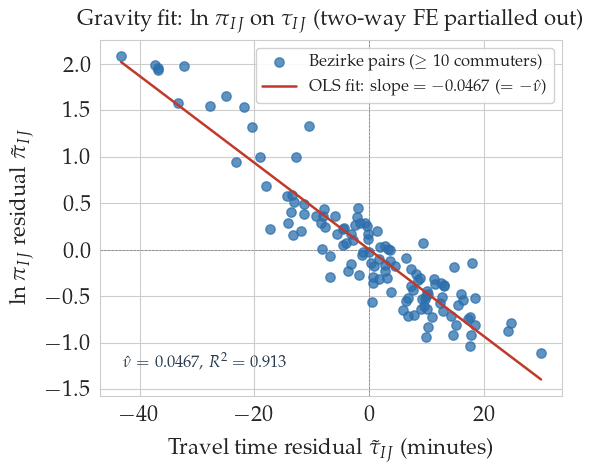

Saved: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/Topic_7/plots/fig4a_gravity_fwl_scatter.png


In [11]:
# ── Figure 4A equivalent: residualized gravity scatter ────────────────────────
# Uses the Column (2) sample (≥10 commuters) and OLS spec to match ARSW.
# FWL: partial out two-way FEs from both ln(π) and τ,
# then scatter the residuals. Slope of fitted line = −ν̂.

df_plot = df_min10.copy()
df_plot["ln_pi_resid"] = partial_out_fe(df_plot["ln_pi"], df_plot["res_fe"], df_plot["work_fe"])
df_plot["tau_resid"]   = partial_out_fe(df_plot["tau"],   df_plot["res_fe"], df_plot["work_fe"])

nu_hat_col2 = res_2.params["tau"]
x_fit = np.linspace(df_plot["tau_resid"].min(), df_plot["tau_resid"].max(), 200)
y_fit = nu_hat_col2 * x_fit   # fitted line through origin (after demeaning)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    df_plot["tau_resid"],
    df_plot["ln_pi_resid"],
    color="#2c6fad",
    alpha=0.75,
    s=45,
    zorder=3,
    label=r"Bez\-irke pairs ($\geq 10$ commuters)",
)

ax.plot(
    x_fit,
    y_fit,
    color="#c0392b",
    linewidth=1.8,
    zorder=4,
    label=rf"OLS fit: slope $= {nu_hat_col2:.4f}$ ($= -\hat{{\nu}}$)",
)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax.axvline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)

ax.set_xlabel(r"Travel time residual $\tilde{\tau}_{IJ}$ (minutes)", labelpad=8)
ax.set_ylabel(r"$\ln \pi_{IJ}$ residual $\tilde{\pi}_{IJ}$", labelpad=8)
ax.set_title(
    r"Gravity fit: $\ln \pi_{IJ}$ on $\tau_{IJ}$ (two-way FE partialled out)",
    pad=10,
)
ax.legend(frameon=True, framealpha=0.9, fontsize=12)

# Annotate with ν̂ and R² from Column (2)
r2_col2 = res_2.rsquared
ax.annotate(
    rf"$\hat{{\nu}} = {abs(nu_hat_col2):.4f}$, $R^2 = {r2_col2:.3f}$",
    xy=(0.05, 0.08),
    xycoords="axes fraction",
    fontsize=12,
    color="#2c3e50",
)

save_path = PLOT_ROOT / "fig4a_gravity_fwl_scatter.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

In [12]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("══════════════════════════════════════════════════════════════════════")
print("  Task 1(a) — Commuting Gravity Regression Results")
print("══════════════════════════════════════════════════════════════════════")
print()
print(f"  Estimated ν̂ = εκ  (semi-elasticity of commuting w.r.t. travel time)")
print()
print(f"  (1) OLS, all pairs       :  ν̂ = {abs(res_1.params['tau']):.4f}  "
      f"(SE = {res_1.bse['tau']:.4f},  R² = {res_1.rsquared:.3f},  N = {len(df_full)})")
print(f"  (2) OLS, ≥10 commuters   :  ν̂ = {abs(res_2.params['tau']):.4f}  "
      f"(SE = {res_2.bse['tau']:.4f},  R² = {res_2.rsquared:.3f},  N = {len(df_min10)})")
print(f"  (3) Poisson PML          :  ν̂ = {abs(res_3.params['tau']):.4f}  "
      f"(SE = {res_3.bse['tau']:.4f},  N = {len(df_min10)})")
print(f"  (4) Gamma PML            :  ν̂ = {abs(res_4.params['tau']):.4f}  "
      f"(SE = {res_4.bse['tau']:.4f},  N = {len(df_min10)})")
print()
print(f"  ARSW (2015) benchmark    :  ν̂ = 0.0702  (Table III, Col 2)")
print()
print(f"  Each extra minute of travel time reduces commuting probability by ~{abs(res_2.params['tau'])*100:.1f}%.")
print()
print(f"  → This ν̂ = εκ is the input to Step 1(b): use optimepsilon_TD86.m")
print(f"    to disentangle ε and κ from the wage dispersion in West Berlin 1986.")
print("══════════════════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════════════════
  Task 1(a) — Commuting Gravity Regression Results
══════════════════════════════════════════════════════════════════════

  Estimated ν̂ = εκ  (semi-elasticity of commuting w.r.t. travel time)

  (1) OLS, all pairs       :  ν̂ = 0.0482  (SE = 0.0019,  R² = 0.897,  N = 144)
  (2) OLS, ≥10 commuters   :  ν̂ = 0.0467  (SE = 0.0020,  R² = 0.913,  N = 122)
  (3) Poisson PML          :  ν̂ = 0.0538  (SE = 0.0020,  N = 122)
  (4) Gamma PML            :  ν̂ = 0.0470  (SE = 0.0016,  N = 122)

  ARSW (2015) benchmark    :  ν̂ = 0.0702  (Table III, Col 2)

  Each extra minute of travel time reduces commuting probability by ~4.7%.

  → This ν̂ = εκ is the input to Step 1(b): use optimepsilon_TD86.m
    to disentangle ε and κ from the wage dispersion in West Berlin 1986.
══════════════════════════════════════════════════════════════════════
